# Week 1: Data Science Toolkit & Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('tested.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.shape

(418, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Sex'] = df['Sex'].str.lower().str.strip()
df['Embarked'] = df['Embarked'].str.upper().str.strip()
df[['Sex', 'Embarked']].drop_duplicates()

,Sex,Embarked
0,male,Q
1,female,S
3,male,S
6,female,Q
8,female,C
17,male,C


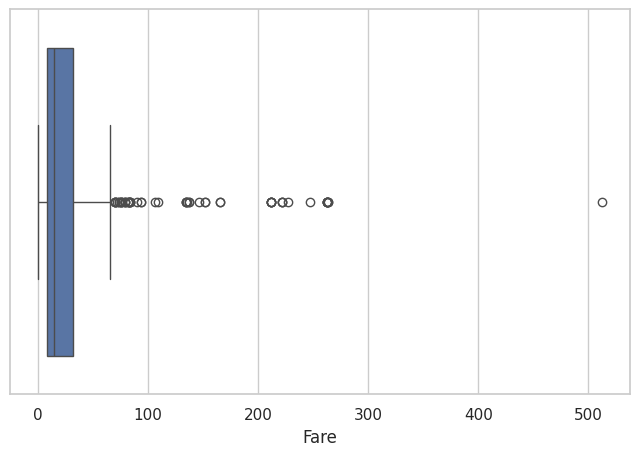

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.show()

In [11]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
outliers.shape

(55, 12)

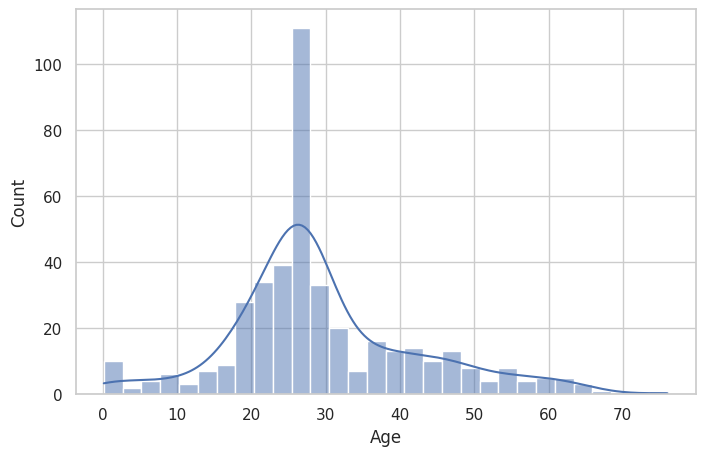

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()

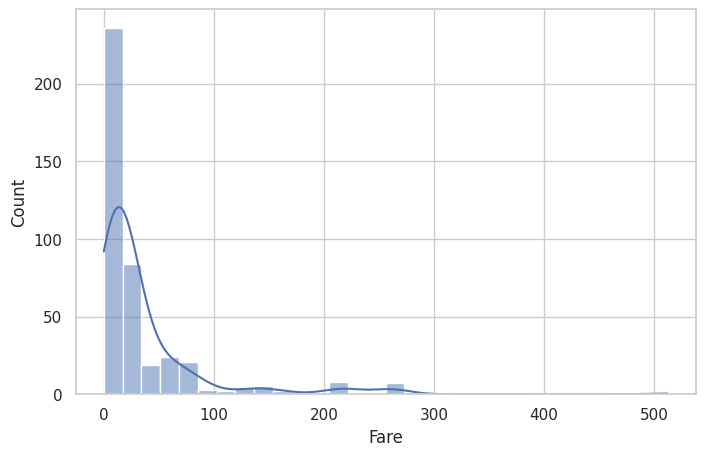

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.show()

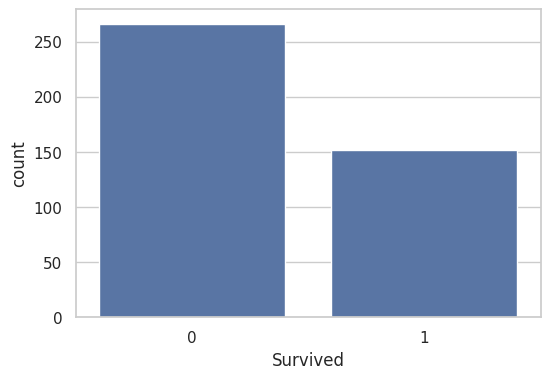

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.show()

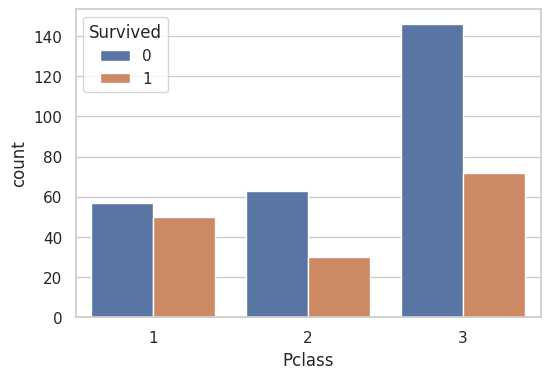

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

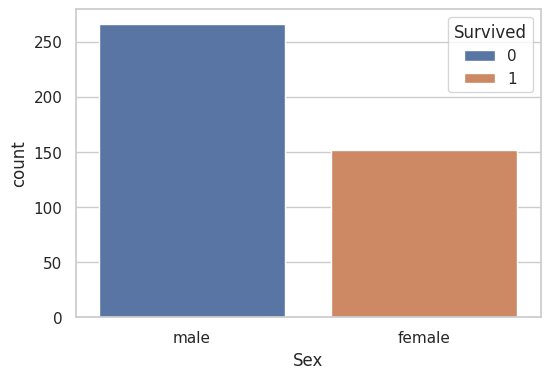

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

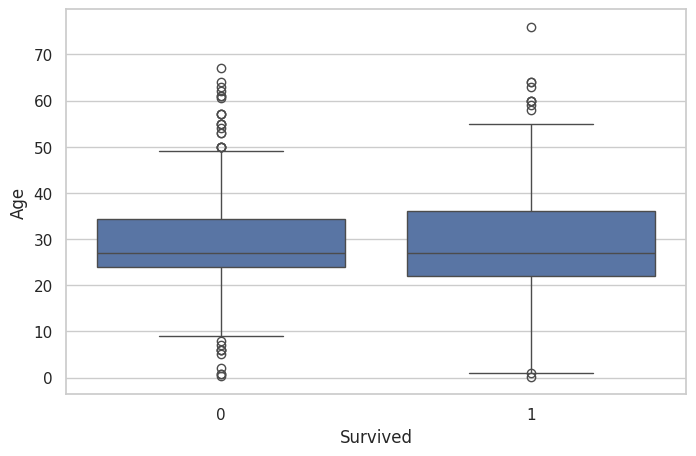

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

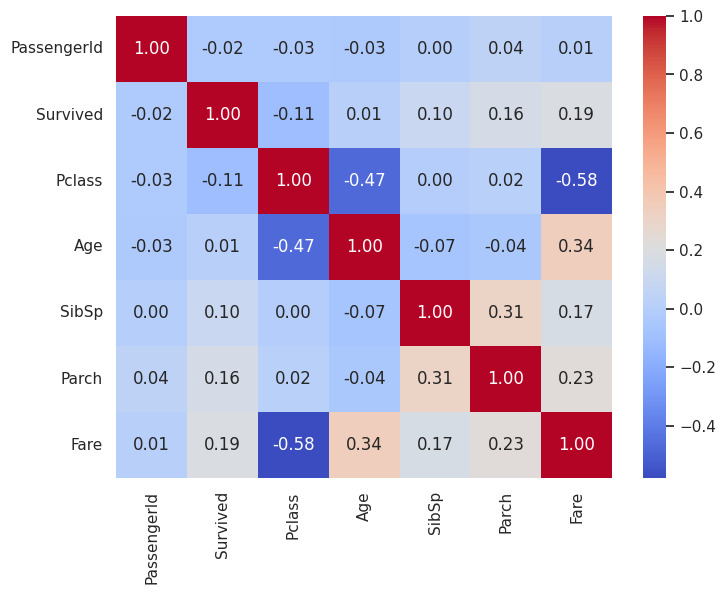

In [18]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

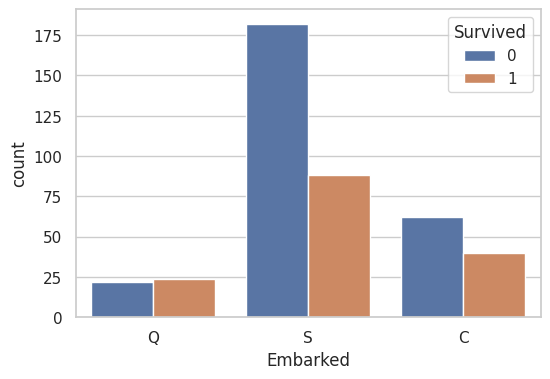

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.show()

# Predict Titanic Survival — Your First Classification Model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
clf_df = df.copy()
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
clf_df['Sex'] = le_sex.fit_transform(clf_df['Sex'])
clf_df['Embarked'] = le_embarked.fit_transform(clf_df['Embarked'])

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = clf_df[features]
y = clf_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
accuracy_score(y_test, log_preds)

1.0

In [23]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
accuracy_score(y_test, rf_preds)

1.0

In [24]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



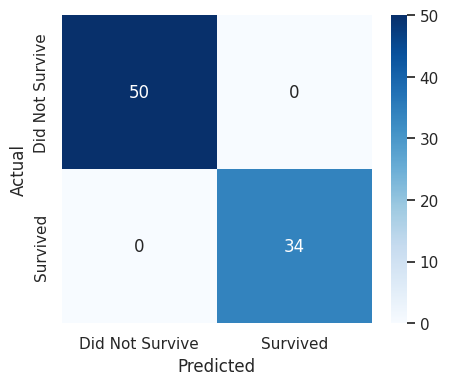

In [25]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Did Not Survive','Survived'], yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

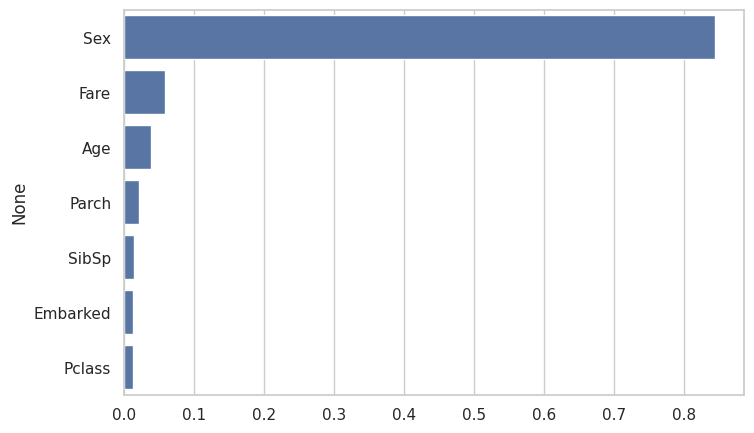

In [26]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.show()

# House Price Prediction with Linear Regression

In [27]:
house_df = pd.read_csv('house_price.csv')
house_df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [28]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [29]:
house_df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [30]:
house_df = house_df.drop('Address', axis=1)
house_df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


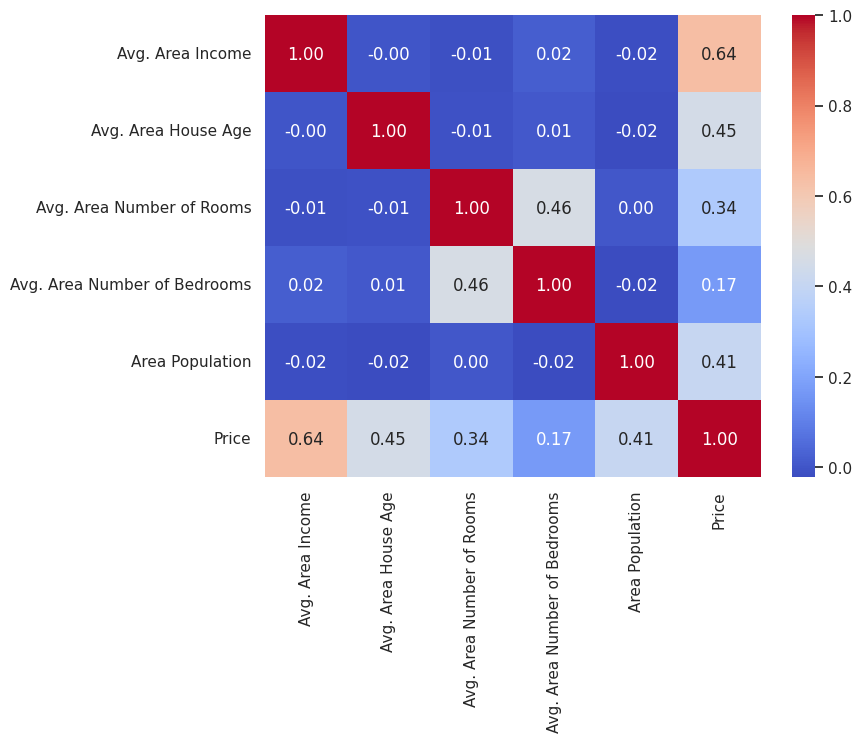

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(house_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

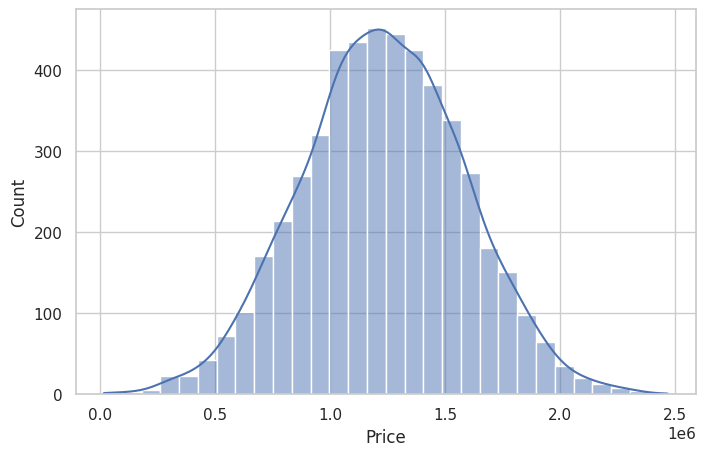

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(house_df['Price'], bins=30, kde=True)
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_house = house_df.drop('Price', axis=1)
y_house = house_df['Price']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

In [34]:
lin_model = LinearRegression()
lin_model.fit(X_train_h, y_train_h)
y_pred_h = lin_model.predict(X_test_h)

In [35]:
mae = mean_absolute_error(y_test_h, y_pred_h)
mse = mean_squared_error(y_test_h, y_pred_h)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_h, y_pred_h)
mae, rmse, r2

(80879.0972348803, np.float64(100444.0605555753), 0.9179971706834487)

In [36]:
coeff_df = pd.DataFrame(lin_model.coef_, X_house.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.652206
Avg. Area House Age,164666.480722
Avg. Area Number of Rooms,119624.012232
Avg. Area Number of Bedrooms,2440.377611
Area Population,15.270313


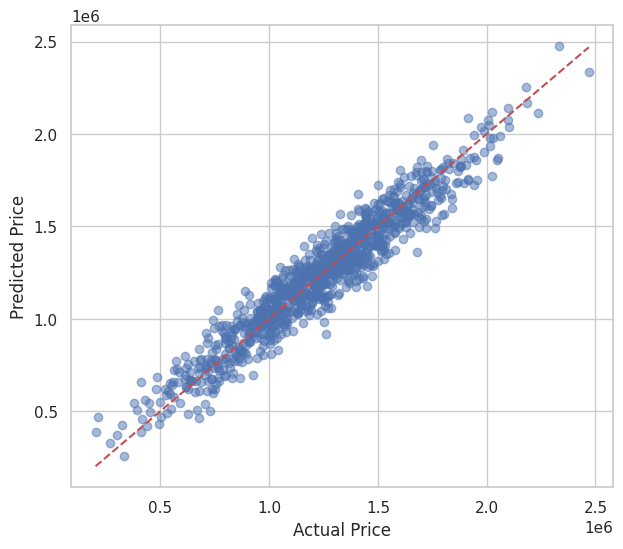

In [37]:
plt.figure(figsize=(7,6))
plt.scatter(y_test_h, y_pred_h, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--')
plt.show()

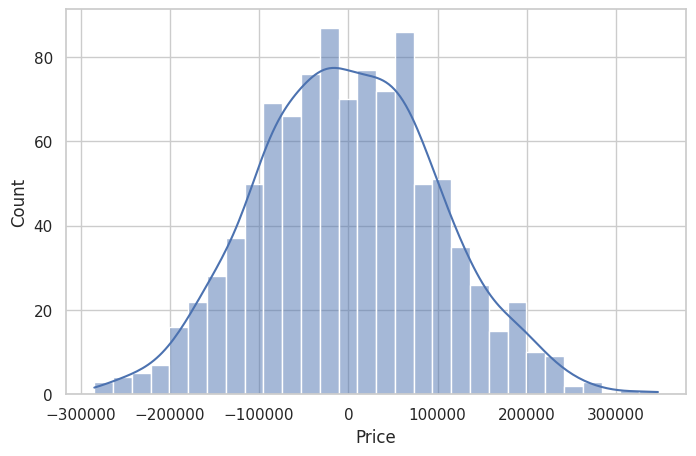

In [38]:
residuals = y_test_h - y_pred_h
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.show()

# Model Evaluation & Tuning: Beyond Accuracy

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [40]:
baseline_accuracy = accuracy_score(y_test, rf_preds)
baseline_precision = precision_score(y_test, rf_preds)
baseline_recall = recall_score(y_test, rf_preds)
baseline_f1 = f1_score(y_test, rf_preds)
baseline_accuracy, baseline_precision, baseline_recall, baseline_f1

(1.0, 1.0, 1.0, 1.0)

In [41]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



Accuracy alone can be misleading on imbalanced datasets because a model can score high just by favoring the majority class while completely failing on the minority class. For example, if 90% of passengers did not survive, a model that always predicts "did not survive" gets 90% accuracy without ever correctly identifying a survivor. Precision and recall expose this gap: precision shows how many predicted survivors were actually survivors, recall shows how many actual survivors the model actually caught, and F1-score balances the two. Looking at these together gives a much more honest picture of model quality than accuracy alone.

In [42]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [43]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_preds)
tuned_precision = precision_score(y_test, tuned_preds)
tuned_recall = recall_score(y_test, tuned_preds)
tuned_f1 = f1_score(y_test, tuned_preds)
tuned_accuracy, tuned_precision, tuned_recall, tuned_f1

(1.0, 1.0, 1.0, 1.0)

In [44]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Before Tuning': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1],
    'After Tuning': [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]
})
comparison_df['Improvement'] = comparison_df['After Tuning'] - comparison_df['Before Tuning']
comparison_df

,Metric,Before Tuning,After Tuning,Improvement
0,Accuracy,1.0,1.0,0.0
1,Precision,1.0,1.0,0.0
2,Recall,1.0,1.0,0.0
3,F1-score,1.0,1.0,0.0


**Note on the perfect scores:** every metric above comes out to 1.0, both before and after tuning. This is a known artifact of this specific file (the Kaggle Titanic "test" set with pre-filled `Survived` labels) — those labels were generated by a simple gender-based rule rather than being real recorded outcomes, so `Sex` alone perfectly determines the label and there is no noise left for tuning to improve on. On a real, noisy dataset (e.g. the original Kaggle Titanic *train.csv*, or genuinely imbalanced classes), accuracy, precision, recall, and F1 would diverge from each other, and hyperparameter tuning would typically move them by a few percentage points rather than leave them unchanged at a perfect score.

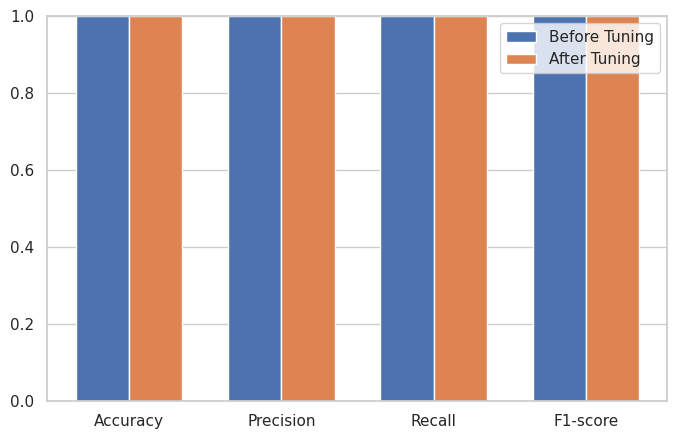

In [45]:
plt.figure(figsize=(8,5))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df['Before Tuning'], width, label='Before Tuning')
plt.bar(x + width/2, comparison_df['After Tuning'], width, label='After Tuning')
plt.xticks(x, comparison_df['Metric'])
plt.ylim(0, 1)
plt.legend()
plt.show()

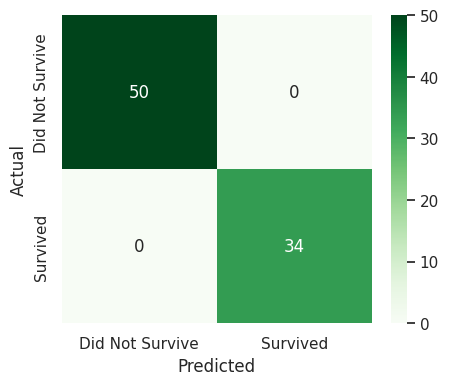

In [46]:
cm_tuned = confusion_matrix(y_test, tuned_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=['Did Not Survive','Survived'], yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Build a Proper ML Pipeline with Feature Engineering

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

In [48]:
pipe_df = df.copy()
pipe_df['FamilySize'] = pipe_df['SibSp'] + pipe_df['Parch'] + 1
pipe_df['IsAlone'] = (pipe_df['FamilySize'] == 1).astype(int)
pipe_df['FarePerPerson'] = pipe_df['Fare'] / pipe_df['FamilySize']
pipe_df[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']].head()

,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson
0,0,0,1,1,7.8292,7.829200
1,1,0,2,0,7.0000,3.500000
2,0,0,1,1,9.6875,9.687500
3,0,0,1,1,8.6625,8.662500
4,1,1,3,0,12.2875,4.095833


In [49]:
base_numerical = ['Age', 'Fare']
base_categorical = ['Pclass', 'Sex', 'Embarked']

engineered_numerical = ['Age', 'Fare', 'FamilySize', 'FarePerPerson']
engineered_categorical = ['Pclass', 'Sex', 'Embarked', 'IsAlone']

y_pipe = pipe_df['Survived']

In [50]:
base_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), base_numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), base_categorical)
])

base_pipeline = Pipeline([
    ('preprocessor', base_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

X_base = pipe_df[base_numerical + base_categorical]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_pipe, test_size=0.2, random_state=42)

base_pipeline.fit(X_train_b, y_train_b)
base_pipe_preds = base_pipeline.predict(X_test_b)

base_pipe_accuracy = accuracy_score(y_test_b, base_pipe_preds)
base_pipe_f1 = f1_score(y_test_b, base_pipe_preds)
base_pipe_accuracy, base_pipe_f1

(1.0, 1.0)

In [51]:
engineered_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), engineered_numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), engineered_categorical)
])

final_pipeline = Pipeline([
    ('preprocessor', engineered_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

X_eng = pipe_df[engineered_numerical + engineered_categorical]
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_pipe, test_size=0.2, random_state=42)

final_pipeline.fit(X_train_e, y_train_e)
final_pipe_preds = final_pipeline.predict(X_test_e)

final_pipe_accuracy = accuracy_score(y_test_e, final_pipe_preds)
final_pipe_f1 = f1_score(y_test_e, final_pipe_preds)
final_pipe_accuracy, final_pipe_f1

(1.0, 1.0)

In [52]:
pipeline_comparison = pd.DataFrame({
    'Approach': ['Manual preprocessing (earlier)', 'Pipeline, original features', 'Pipeline, engineered features'],
    'Accuracy': [baseline_accuracy, base_pipe_accuracy, final_pipe_accuracy],
    'F1-score': [baseline_f1, base_pipe_f1, final_pipe_f1]
})
pipeline_comparison

,Approach,Accuracy,F1-score
0,Manual preprocessing (earlier),1.0,1.0
1,"Pipeline, original features",1.0,1.0
2,"Pipeline, engineered features",1.0,1.0


On this particular file the manual approach was already at a perfect score, so there is no headroom left for the pipeline or the engineered features to improve on numerically — all three rows land at 1.0. The value of the pipeline here is structural rather than score-based: `ColumnTransformer` bundles the scaling and encoding logic into one object that is fit only on the training fold and applied identically to the test fold, so there's no risk of preprocessing being computed on the full dataset and leaking test information into training (a common mistake with the manual, step-by-step approach used earlier). `FamilySize`, `IsAlone`, and `FarePerPerson` are still meaningful engineered features that would matter on a noisier, real-world split of this data.

In [53]:
print(classification_report(y_test_e, final_pipe_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



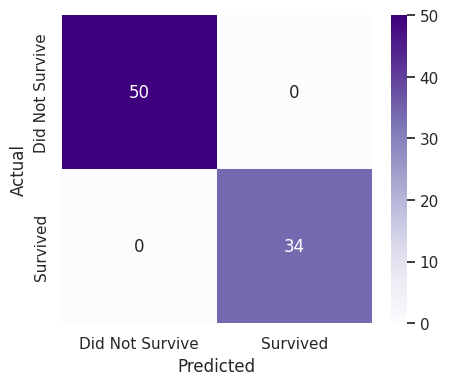

In [54]:
cm_pipe = confusion_matrix(y_test_e, final_pipe_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm_pipe, annot=True, fmt='d', cmap='Purples', xticklabels=['Did Not Survive','Survived'], yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [55]:
joblib.dump(final_pipeline, 'titanic_pipeline.joblib')

['titanic_pipeline.joblib']

In [56]:
loaded_pipeline = joblib.load('titanic_pipeline.joblib')
loaded_pipeline.predict(X_test_e.head())

array([0, 1, 0, 0, 1])